## Machine Learning

### Linear Regression

In [83]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['monthly_rent'])
y = df['monthly_rent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = ['rooms', 'parking', 'bathroom', 'size', 'property_age']

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X_train_lr = one_hot_encode(X_train)
X_test_lr = one_hot_encode(X_test)

# align columns (important!)
X_train_lr, X_test_lr = X_train_lr.align(X_test_lr, join='left', axis=1, fill_value=0)

# Scale with standardscaler
scaler = StandardScaler()
X_train_lr[num_cols] = scaler.fit_transform(X_train_lr[num_cols])
X_test_lr[num_cols] = scaler.transform(X_test_lr[num_cols])

In [85]:
lr = LinearRegression()
lr.fit(X_train_lr, y_train)

y_pred_lr = lr.predict(X_test_lr)

### Random Forest Regressor

In [86]:
X_train_rf = one_hot_encode(X_train)
X_test_rf = one_hot_encode(X_test)

X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join='left', axis=1, fill_value=0)

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    # n_estimators = 100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train)

y_pred_rf = rf.predict(X_test_rf)

### Gradient Boosting Regressor

In [87]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_rf, y_train)

y_pred_gbr = gbr.predict(X_test_rf)

### CatBoost

In [88]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

cat_features = [
    'location',
    'property_type',
    'region'
]

cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=100,
    random_state=42
)

cb.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

y_pred_cb = cb.predict(X_test)

0:	learn: 900.3529073	total: 29.4ms	remaining: 29.3s
100:	learn: 434.7605241	total: 4.14s	remaining: 36.9s
200:	learn: 380.6513062	total: 8.44s	remaining: 33.5s
300:	learn: 348.8543096	total: 12.3s	remaining: 28.7s
400:	learn: 324.0420455	total: 16s	remaining: 23.9s
500:	learn: 305.8129790	total: 19.6s	remaining: 19.5s
600:	learn: 290.7623710	total: 23.4s	remaining: 15.6s
700:	learn: 279.3467376	total: 27.2s	remaining: 11.6s
800:	learn: 268.5037031	total: 30.9s	remaining: 7.68s
900:	learn: 259.4913843	total: 34.5s	remaining: 3.79s
999:	learn: 250.0686367	total: 38.4s	remaining: 0us


### XGBoost

In [89]:
X_train_xgb = one_hot_encode(X_train)
X_test_xgb = one_hot_encode(X_test)

X_train_xgb, X_test_xgb = X_train_xgb.align(
    X_test_xgb,
    join='left',
    axis=1,
    fill_value=0
)

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_xgb, y_train)
y_pred_xgb = xgb.predict(X_test_xgb)

### MLP Regressor

In [90]:
if train_MLP:
    from sklearn.neural_network import MLPRegressor
    
    scaler = StandardScaler()
    
    X_train_nn = one_hot_encode(X_train)
    X_test_nn = one_hot_encode(X_test)
    
    num_cols = [
        'parking',
        'bathroom',
        'size',
        'property_age'
    ]
    
    X_train_nn[num_cols] = scaler.fit_transform(X_train_nn[num_cols])
    X_test_nn[num_cols] = scaler.transform(X_test_nn[num_cols])
    
    X_train_nn, X_test_nn = X_train_nn.align(X_test_nn, join='left', axis=1, fill_value=0)
    
    mlp = MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    
    mlp.fit(X_train_nn, y_train)
    
    y_pred_mlp = mlp.predict(X_test_nn)

### Model Evaluation

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.4f}")
    print("-"*30)

In [92]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)

results = []

if train_MLP:
    models = [
        ("Linear Regression", y_pred_lr),
        ("Random Forest", y_pred_rf),
        ("Gradient Boosting", y_pred_gbr),
        ("CatBoost", y_pred_cb),
        ("XGBoost", y_pred_xgb),
        ("MLP", y_pred_mlp)
    ]
else:
    models = [
        ("Linear Regression", y_pred_lr),
        ("Random Forest", y_pred_rf),
        ("Gradient Boosting", y_pred_gbr),
        ("CatBoost", y_pred_cb),
        ("XGBoost", y_pred_xgb)
    ]

for name, pred in models:

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    evs = explained_variance_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R²": round(r2, 4),
        "Explained Variance": round(evs, 4)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
)

results_df

,Model,MAE,MSE,RMSE,R²,Explained Variance
3,CatBoost,230.10,299364.82,547.14,0.7100,0.7106
1,Random Forest,211.89,299894.70,547.63,0.7095,0.7101
4,XGBoost,240.02,311288.50,557.93,0.6985,0.6988
5,MLP,256.92,339795.98,582.92,0.6708,0.6708
2,Gradient Boosting,292.92,351351.81,592.75,0.6596,0.6598
0,Linear Regression,354.98,486680.93,697.63,0.5286,0.5288


### Hyperparameter Tuning for XGBoost, CatBoost and Random Forest

In [93]:
if hyperparameter_tuning_RandomForest:
    from sklearn.model_selection import RandomizedSearchCV
    
    rf_params = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    rf_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        rf_params,
        n_iter=20,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    
    rf_search.fit(X_train_rf, y_train)
    
    print(rf_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [94]:
    
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train_rf, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test_rf)

evaluate(y_test, y_pred_rf, "Original Random Forest")
evaluate(y_test, y_pred_rf_tuned, "Tuned Random Forest")

Original Random Forest
MAE: 211.89
RMSE: 547.63
R2: 0.7095
------------------------------
Tuned Random Forest
MAE: 211.50
RMSE: 547.41
R2: 0.7097
------------------------------


In [95]:
if hyperparameter_tuning_XGBoost:

    from xgboost import XGBRegressor
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np
    
    # Parameter space
    xgb_params = {
        'n_estimators': [300, 500, 800, 1000],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
    }
    
    xgb_search = RandomizedSearchCV(
        estimator=XGBRegressor(
            objective='reg:squarederror',
            random_state=42
        ),
        param_distributions=xgb_params,
        n_iter=10,
        cv=5,
        scoring='neg_root_mean_squared_error',
        verbose=3,          # SHOW PROGRESS
        random_state=42,
        n_jobs=-1
    )
    
    print("Starting XGBoost tuning...")
    xgb_search.fit(X_train_xgb, y_train)
    
    print("\nBest Parameters:")
    print(xgb_search.best_params_)
    
    print("\nBest CV RMSE:")
    print(-xgb_search.best_score_)
    
    # Evaluate tuned model
    best_xgb = xgb_search.best_estimator_

else:
    # Train the tuned model using parameters obtained from tuning
    print("Skipping tuning. Using predefined best parameters.")

    best_xgb = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        subsample=0.7,
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        colsample_bytree=0.9
    )

    best_xgb.fit(X_train_xgb, y_train)

y_pred_xgb_tuned = best_xgb.predict(X_test_xgb)

evaluate(y_test, y_pred_xgb_tuned, "Tuned XGBoost")
evaluate(y_test, y_pred_xgb, "Original XGBoost")


Starting XGBoost tuning...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'subsample': 0.7, 'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Best CV RMSE:
414.3097744937883
Tuned XGBoost
MAE: 223.17
RMSE: 542.32
R2: 0.7151
------------------------------
Original XGBoost
MAE: 240.02
RMSE: 557.93
R2: 0.6985
------------------------------


In [96]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV

if hyperparameter_tuning_CatBoost:

    param_dist = {
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "iterations": [300, 500, 800, 1000],
        "l2_leaf_reg": [1, 3, 5, 7, 9]
    }

    cat_model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=0
    )

    search = RandomizedSearchCV(
        estimator=cat_model,
        param_distributions=param_dist,
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=2
    )

    print("Starting CatBoost tuning...")
    search.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    best_model = search.best_estimator_

    print("Best params:", search.best_params_)

else:
    # Fallback using known best parameters
    print("Skipping tuning. Using predefined best CatBoost parameters.")

    best_model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=42,
        verbose=0,
        depth=8,
        learning_rate=0.05,
        iterations=800,
        l2_leaf_reg=1
    )

    best_model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

# =========================
# Common evaluation block
# =========================

y_pred_cb_tuned = best_model.predict(X_test)

evaluate(y_test, y_pred_cb_tuned, "Tuned CatBoost")
evaluate(y_test, y_pred_cb, "Original CatBoost")

Starting CatBoost tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 800, 'depth': 8}
Tuned CatBoost
MAE: 229.10
RMSE: 543.47
R2: 0.7139
------------------------------
Original CatBoost
MAE: 230.10
RMSE: 547.14
R2: 0.7100
------------------------------


In [97]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)

import pandas as pd
import numpy as np

models = [
    ("Linear Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("Gradient Boosting", y_pred_gbr),
    ("CatBoost", y_pred_cb),
    ("XGBoost", y_pred_xgb),
]
if train_MLP:
    models.append(("MLP", y_pred_mlp))
models.append(("Tuned Random Forest", y_pred_rf_tuned))
models.append(("Tuned CatBoost", y_pred_cb_tuned))
models.append(("Tuned XGBoost", y_pred_xgb_tuned))

results = []

for name, pred in models:

    results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 2),
        "R²": round(r2_score(y_test, pred), 4),
        "Explained Variance": round(
            explained_variance_score(y_test, pred), 4
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R²",
    ascending=False
)

,Model,MAE,RMSE,R²,Explained Variance
8,Tuned XGBoost,223.17,542.32,0.7151,0.7154
7,Tuned CatBoost,229.10,543.47,0.7139,0.7143
3,CatBoost,230.10,547.14,0.7100,0.7106
6,Tuned Random Forest,211.50,547.41,0.7097,0.7103
1,Random Forest,211.89,547.63,0.7095,0.7101
4,XGBoost,240.02,557.93,0.6985,0.6988
5,MLP,256.92,582.92,0.6708,0.6708
2,Gradient Boosting,292.92,592.75,0.6596,0.6598
0,Linear Regression,354.98,697.63,0.5286,0.5288


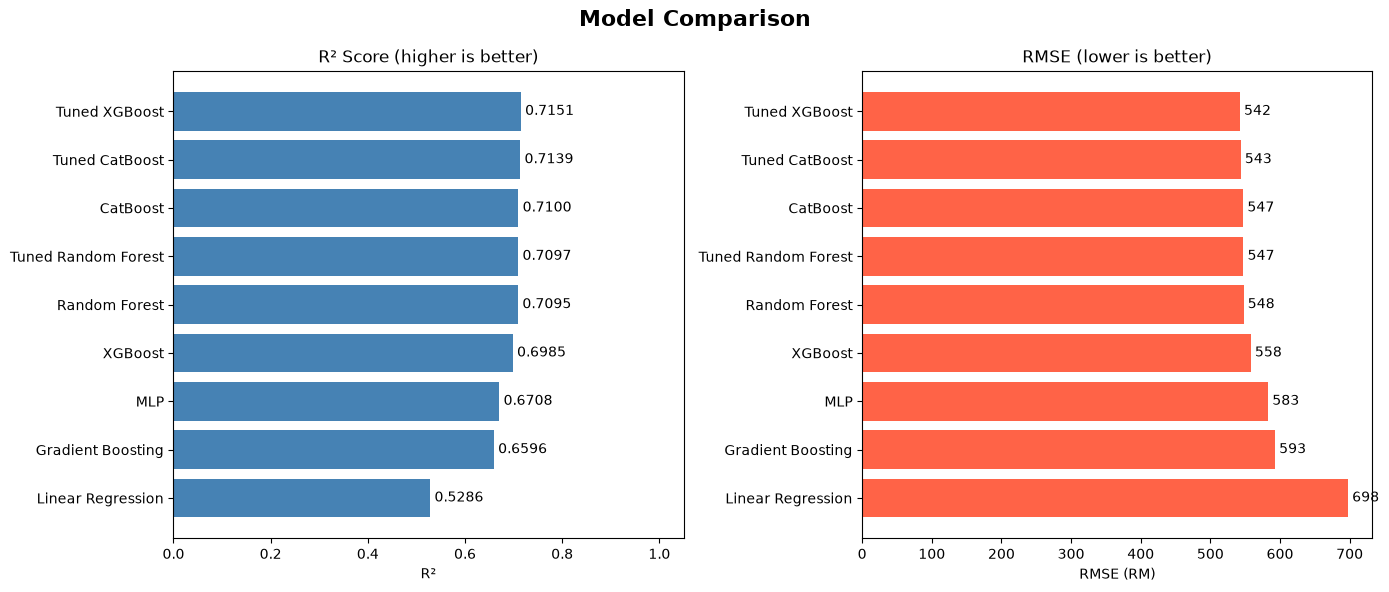

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

results_sorted_r2 = results_df.sort_values('R²', ascending=True)
results_sorted_rmse = results_df.sort_values('RMSE', ascending=False)

# R² bar chart
bars = axes[0].barh(results_sorted_r2['Model'], results_sorted_r2['R²'], color='steelblue')
axes[0].set_title('R² Score (higher is better)')
axes[0].set_xlabel('R²')
axes[0].bar_label(bars, fmt='%.4f', padding=3)
axes[0].set_xlim(0, 1.05)

# RMSE bar chart
bars2 = axes[1].barh(results_sorted_rmse['Model'], results_sorted_rmse['RMSE'], color='tomato')
axes[1].set_title('RMSE (lower is better)')
axes[1].set_xlabel('RMSE (RM)')
axes[1].bar_label(bars2, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()